In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

from jaqalpaq import run
from jaqalpaq import emulator
from jaqalpaq.run import run_jaqal_file, run_jaqal_string, run_jaqal_batch, run_jaqal_circuit, frontend

from jaqalpaq.emulator.unitary import UnitarySerializedEmulator
emulator_backend = UnitarySerializedEmulator()
from qscout.v1.std.noisy import SNLToy1

from jaqalpaq.qsyntax import circuit
from jaqalpaq.generator import generate_jaqal_program
from jaqalpaq.core.algorithm import expand_subcircuits

In [2]:
#Define your Jaqal circuit

jaqal_string="""from Calibration_PulseDefinitions.UserPulses usepulses *


let pi   3.1415926535897
let pi_2 1.57079
let num_gates 2
let ms_angle 1.57079


register q[2]
subcircuit{

loop num_gates{
    //Sy q[1]
    MS q[0] q[1] 0 ms_angle
}

}  
"""

In [3]:
emulator = 1
from qscout.v1.std.noisy import SNLToy1
#import pygsti
#from pygsti.modelpacks import smq2Q_XYXX

#Parameter Tracking for a Nelder-Mead optimization
amp_tracker = []
zeta_tracker = []
framerot_tracker = []
non_11_pop_tracker = []

#Define number of gates in your loop
num_gates = 2
ms_angle = np.pi/2

def optimizer_step(params):
    
    #Here are the parameters we're thinking about varying
    amp_ia = params[0] #Typically a max of 100, since the amplitude and zeta are intertwined (and diff per qubit), we'll need to think more about how to properly bound this
    zeta = params[1] #blue/red ratio, usually around 1.05
    framerot = params[2] #light shift correction, -180 to 180 degrees
    
    #Here we're defining a simple error model based on Jaqal's SNLToy1
    delta_theta = (amp_ia*(np.pi/80) - np.pi/2) / 10 #SNLToy1 is silly, it multiples the rotation error by a factor of 10 for all two qubit gates, same for depolarization and phase error
    depolarization = 2e-5+2e-2*(zeta-1.05)**2
    #delta_phi = (framerot + 20) #Couldn't get framerot to act properly in this simple error model
    noisy_model = SNLToy1(2,rotation_error=delta_theta, depolarization = depolarization) #phase_error = delta_phi)

    
    #Run on the emulator with noisy model
    if emulator:
        #Define the override dictionary to change parameters in the jaqal file
        overrides = {'ms_angle': ms_angle,
                     'num_gates': num_gates,
                     '__repeats__': 200}
        #Run and return results object
        results = run_jaqal_string(jaqal_string.replace('from Calibration_PulseDefinitions.UserPulses usepulses *','from qscout.v1.std usepulses *'), 
                                       #backend = emulator_backend,
                                       backend = noisy_model, 
                                       overrides = overrides)
        #Extract probabilities from the results object
        probs = results.subcircuits[0].probability_by_int #00,01,10,11 (right-most qubit is q[0], left-most is q[1])

        
    #Run on the experiment
    else:
        #Define the override dictionary to change parameters in the jaqal file AND the pulse definitions "pd."
        overrides={'pd.amp_ia': amp_ia,
                   'pd.zeta': zeta,
                   'pd.framerot': framerot,
                   'ms_angle': ms_angle,
                   'num_gates': num_gates,
                   '__repeats__': 200}
        #Run and return results object
        results = run.run_jaqal_string(jaqal_string, overrides=overrides)
        #Extract probabilities from the results object NOTE: The formatting of the results object is sometimes a little different on the experiment vs. the emulator (extra nesting), so we'll need to confirm the actual object shaping
        probs = results.subcircuits[0].probability_by_int #00,01,10,11 (right-most qubit is q[0], left-most is q[1])

    #The cost function we want to minimize for this demo is everything not in 11
    non_11_pop = 1-probs[-1]

    #Fill up variable trackers
    amp_tracker.append(amp_ia)
    zeta_tracker.append(zeta)
    framerot_tracker.append(framerot)
    non_11_pop_tracker.append(non_11_pop)
    
    return non_11_pop #returning everything not in 11

In [4]:
import scipy.optimize as opt
import time

#Start with empty parameter trackers
amp_tracker = []
zeta_tracker = []
framerot_tracker = []
non_11_pop_tracker = []

start = time.time()
#Optimize!
result = opt.minimize(fun = optimizer_step, 
                      x0 = (25,.87,0), 
                      bounds = [(0,100),(0.5,1.5),(-180,180)],
                      tol = (0.01), 
                      method = 'Nelder-Mead', 
                      options = {'maxiter': 50})
end = time.time()
elapsed = end - start
print(elapsed)
#print(amp_tracker)
#print(zeta_tracker)
#print(framerot_tracker)
#print(non_11_pop_tracker)

1.3636441230773926


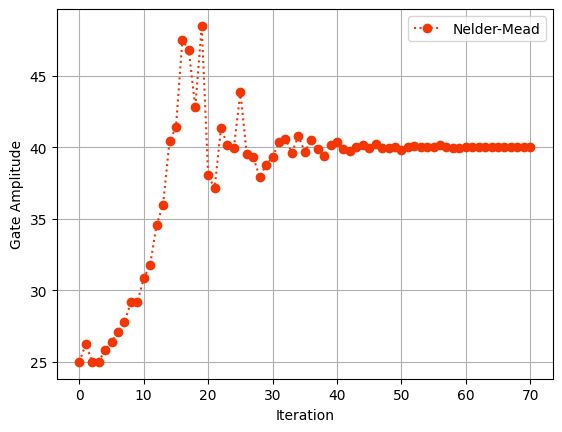

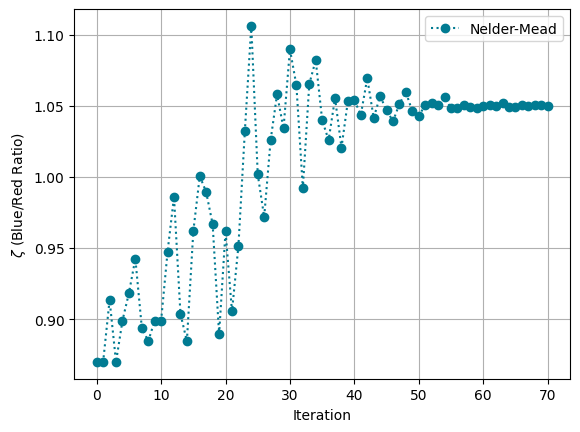

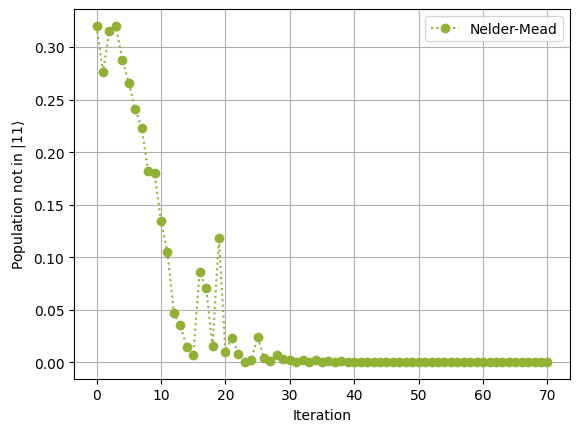

In [5]:
#Plot how the parameters changed throughout the optimization, note I'm not including the frame rotation since it is largely staying fixed not having a pathway in the noisy simulator

fig1 = plt.figure(1)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('Gate Amplitude')
plt.grid()
plt.plot([r for r in range(0,len(amp_tracker))],amp_tracker,linestyle = ':', marker = 'o', color = 'xkcd:orangish red', label = 'Nelder-Mead')
plt.legend()

fig2 = plt.figure(2)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('$\\zeta$ (Blue/Red Ratio)')
plt.grid()
plt.plot([r for r in range(0,len(zeta_tracker))],zeta_tracker,linestyle = ':', marker = 'o', color = 'xkcd:ocean', label = 'Nelder-Mead')
plt.legend()

fig3 = plt.figure(3)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('Population not in $|11\\rangle$')
plt.grid()
plt.plot([r for r in range(0,len(non_11_pop_tracker))],non_11_pop_tracker,linestyle = ':', marker = 'o', color = 'xkcd:avocado', label = 'Nelder-Mead')
plt.legend()


plt.show()